# K-Means Clustering
## Dataset: Data Bantal
Notebook ini melakukan clustering konsumen berdasarkan preferensi harga, desain, dan kenyamanan bantal menggunakan algoritma K-Means.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

## 1. Load Dataset

In [2]:
df = pd.read_csv('../dataset/data_bantal.csv')

# Cek dan buang baris yang isinya sama dengan nama kolom (header duplikat)
df = df[df.iloc[:, 0] != df.columns[0]]
df = df.reset_index(drop=True)

df

,ID,Nama Product,Jenis Kelamin,Usia,Harga,Desain,Kenyamanan,Durasi Tidur,Random Forest,Grad. Boosting,Naive Bayes,K-Means,Kesimpulan
0,INSERT INTO data_preferensi (nama,jenis_kelamin,usia,harga,desain,kenyamanan,durasi_tidur,random_forest,gradient_boosting,naive_bayes,kmeans_cluster,kesimpulan) VALUES,NaN
1,('Kece Series','P',23,4,3,1,10,0,1,1,2,'Direkomendasikan'),
2,('Kece Series','L',26,3,5,3,9,0,0,0,2,'Cukup Direkomendasikan'),NaN
3,('Premium Series','P',22,1,3,4,4,0,0,0,1,'Cukup Direkomendasikan'),NaN
4,('Kece Series','P',45,5,4,3,7,0,1,1,3,'Direkomendasikan'),NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,('Kids Signature Series','P',55,2,5,2,5,0,1,0,1,'Cukup Direkomendasikan'),NaN
297,('Signature Series','L',52,4,4,5,10,0,0,0,3,'Cukup Direkomendasikan'),NaN
298,('Kece Series','L',46,5,1,4,5,1,0,0,3,'Cukup Direkomendasikan'),NaN
299,('Deluxe Series','P',54,5,2,2,7,1,1,0,2,'Direkomendasikan'),NaN


In [3]:
df.describe()

,ID,Nama Product,Jenis Kelamin,Usia,Harga,Desain,Kenyamanan,Durasi Tidur,Random Forest,Grad. Boosting,Naive Bayes,K-Means,Kesimpulan
count,301,301,301,301,301,301,301,301,301,301,301,301,1
unique,11,3,43,6,6,6,8,3,3,3,4,4,1
top,('Premium Series','L',48,1,1,1,10,1,0,0,2,'Cukup Direkomendasikan'),
freq,37,156,14,71,67,66,52,157,155,157,104,154,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              301 non-null    object
 1   Nama Product    301 non-null    object
 2   Jenis Kelamin   301 non-null    object
 3   Usia            301 non-null    object
 4   Harga           301 non-null    object
 5   Desain          301 non-null    object
 6   Kenyamanan      301 non-null    object
 7   Durasi Tidur    301 non-null    object
 8   Random Forest   301 non-null    object
 9   Grad. Boosting  301 non-null    object
 10  Naive Bayes     301 non-null    object
 11  K-Means         301 non-null    object
 12  Kesimpulan      1 non-null      object
dtypes: object(13)
memory usage: 30.7+ KB


## 2. Eksplorasi Data Awal

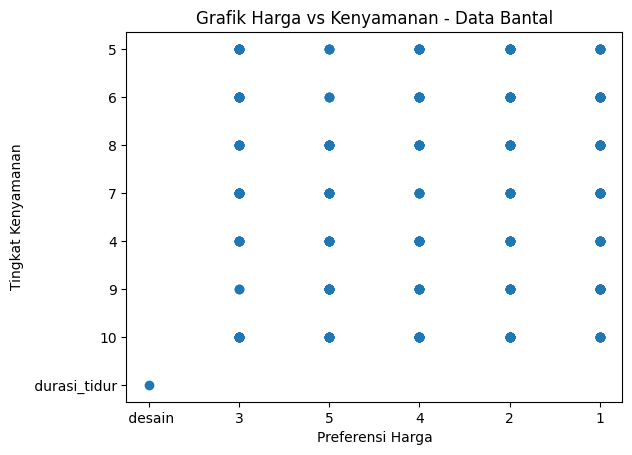

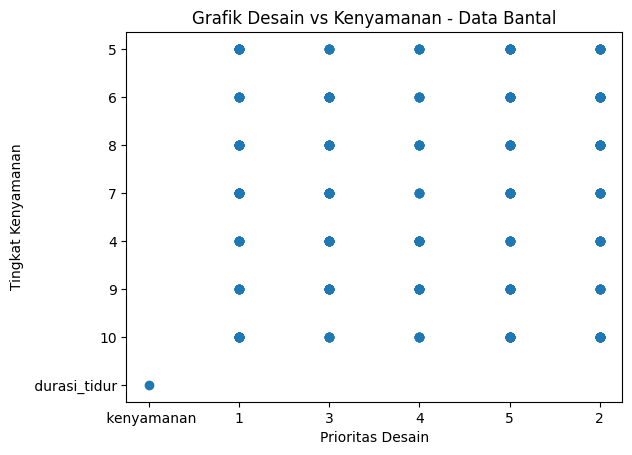

In [5]:
plt.scatter(df['Harga'], df['Kenyamanan'])
plt.xlabel('Preferensi Harga')
plt.ylabel('Tingkat Kenyamanan')
plt.title('Grafik Harga vs Kenyamanan - Data Bantal')
plt.show()

plt.scatter(df['Desain'], df['Kenyamanan'])
plt.xlabel('Prioritas Desain')
plt.ylabel('Tingkat Kenyamanan')
plt.title('Grafik Desain vs Kenyamanan - Data Bantal')
plt.show()

## 3. Preprocessing & Scaling

In [6]:
# Bersihkan nama kolom
df.columns = df.columns.str.strip()

# Hapus baris duplikat header yang mungkin ada di dalam data
for col in df.columns:
    df = df[df[col].astype(str).str.strip().str.lower() != col.lower()]
df = df.reset_index(drop=True)

# Encode kolom kategori
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Jenis Kelamin'] = le.fit_transform(df['Jenis Kelamin'].astype(str).str.strip())

# Pilih fitur untuk clustering
fitur = ['Jenis Kelamin', 'Usia', 'Harga', 'Desain', 'Kenyamanan', 'Durasi Tidur']
x_train = df[fitur].copy()

# Bersihkan data - hapus spasi dan konversi ke numerik
x_train = x_train.apply(lambda col: pd.to_numeric(col.astype(str).str.strip(), errors='coerce'))
x_train = x_train.fillna(0)

# Scaling dengan MinMaxScaler
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)

print("Scaling berhasil!")
print("Shape data:", x_train.shape)

Scaling berhasil!
Shape data: (301, 6)


In [7]:
x_train

array([[1.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.11904762, 0.8       , 0.6       , 0.2       , 1.        ,
        0.        ],
       [0.19047619, 0.6       , 1.        , 0.6       , 0.9       ,
        0.        ],
       ...,
       [0.66666667, 1.        , 0.2       , 0.8       , 0.5       ,
        1.        ],
       [0.85714286, 1.        , 0.4       , 0.4       , 0.7       ,
        1.        ],
       [0.14285714, 1.        , 1.        , 0.2       , 0.7       ,
        1.        ]], shape=(301, 6))

## 4. Elbow Method - Menentukan K Optimal

In [8]:
inertias = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42).fit(x_train)
    inertias.append(km.inertia_)

inertias

[187.44373509315136,
 111.69616612143795,
 100.20947635577392,
 90.59948677244057,
 85.1222408071617,
 78.51695927781037,
 72.99007650492821,
 66.42490936902254,
 64.237173443313]

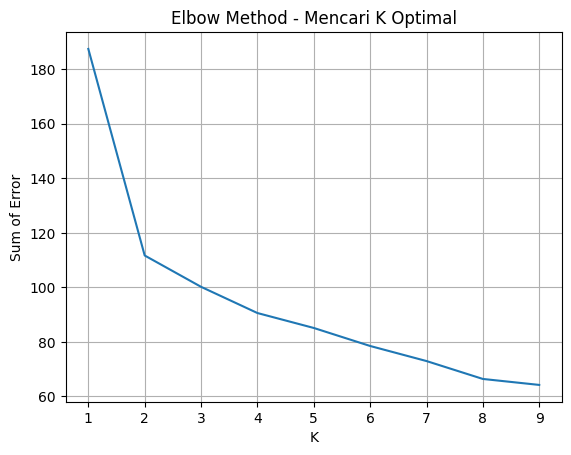

In [9]:
plt.xlabel('K')
plt.ylabel('Sum of Error')
plt.title('Elbow Method - Mencari K Optimal')
plt.plot(k_range, inertias)
plt.grid()
plt.show()

## 5. Training Model K-Means

In [10]:
kmean = KMeans(n_clusters=2, random_state=42)
y_cluster = kmean.fit_predict(x_train)

print("Clustering selesai!")
print("Cluster centers:\n", kmean.cluster_centers_)

Clustering selesai!
Cluster centers:
 [[ 5.10312405e-01  5.78343949e-01  5.98726115e-01  5.91082803e-01
   7.45222930e-01  1.00000000e+00]
 [ 4.97519841e-01  5.83333333e-01  5.51388889e-01  5.76388889e-01
   6.68750000e-01 -6.66133815e-16]]


In [11]:
y_cluster

array([1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0]

In [12]:
df['Cluster'] = y_cluster
df

,ID,Nama Product,Jenis Kelamin,Usia,Harga,Desain,Kenyamanan,Durasi Tidur,Random Forest,Grad. Boosting,Naive Bayes,K-Means,Kesimpulan,Cluster
0,INSERT INTO data_preferensi (nama,jenis_kelamin,42,harga,desain,kenyamanan,durasi_tidur,random_forest,gradient_boosting,naive_bayes,kmeans_cluster,kesimpulan) VALUES,NaN,1
1,('Kece Series','P',5,4,3,1,10,0,1,1,2,'Direkomendasikan'),,1
2,('Kece Series','L',8,3,5,3,9,0,0,0,2,'Cukup Direkomendasikan'),NaN,1
3,('Premium Series','P',4,1,3,4,4,0,0,0,1,'Cukup Direkomendasikan'),NaN,1
4,('Kece Series','P',27,5,4,3,7,0,1,1,3,'Direkomendasikan'),NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,('Kids Signature Series','P',37,2,5,2,5,0,1,0,1,'Cukup Direkomendasikan'),NaN,1
297,('Signature Series','L',34,4,4,5,10,0,0,0,3,'Cukup Direkomendasikan'),NaN,1
298,('Kece Series','L',28,5,1,4,5,1,0,0,3,'Cukup Direkomendasikan'),NaN,0
299,('Deluxe Series','P',36,5,2,2,7,1,1,0,2,'Direkomendasikan'),NaN,0


## 6. Visualisasi Hasil Clustering

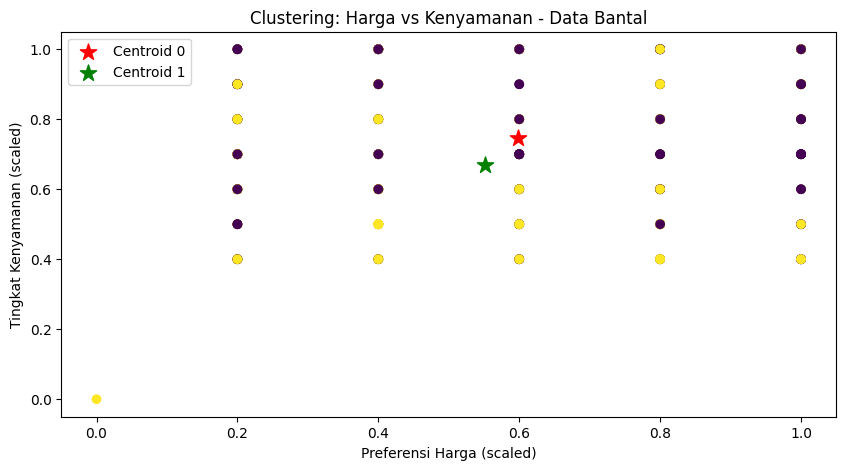

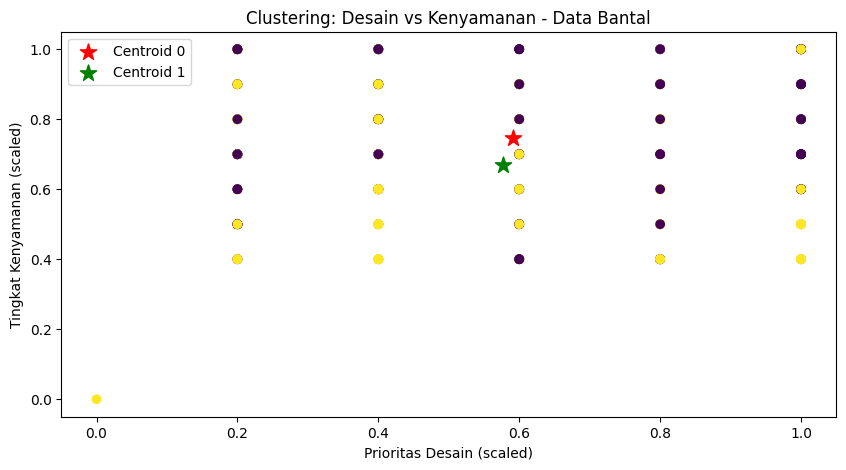

In [13]:
# Indeks fitur: 0=jk, 1=usia, 2=harga, 3=desain, 4=kenyamanan, 5=durasi_tidur
plt.figure(figsize=(10, 5))
plt.scatter(x_train[:, 2], x_train[:, 4], c=kmean.labels_)
plt.scatter(kmean.cluster_centers_[0, 2], kmean.cluster_centers_[0, 4], color='red', marker='*', s=150, label='Centroid 0')
plt.scatter(kmean.cluster_centers_[1, 2], kmean.cluster_centers_[1, 4], color='green', marker='*', s=150, label='Centroid 1')
plt.xlabel('Preferensi Harga (scaled)')
plt.ylabel('Tingkat Kenyamanan (scaled)')
plt.legend()
plt.title('Clustering: Harga vs Kenyamanan - Data Bantal')
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(x_train[:, 3], x_train[:, 4], c=kmean.labels_)
plt.scatter(kmean.cluster_centers_[0, 3], kmean.cluster_centers_[0, 4], color='red', marker='*', s=150, label='Centroid 0')
plt.scatter(kmean.cluster_centers_[1, 3], kmean.cluster_centers_[1, 4], color='green', marker='*', s=150, label='Centroid 1')
plt.xlabel('Prioritas Desain (scaled)')
plt.ylabel('Tingkat Kenyamanan (scaled)')
plt.legend()
plt.title('Clustering: Desain vs Kenyamanan - Data Bantal')
plt.show()

## 7. Labeling Cluster

In [14]:
df['Cluster'] = df['Cluster'].replace([0, 1], ['Non-Premium', 'Premium'])
df

,ID,Nama Product,Jenis Kelamin,Usia,Harga,Desain,Kenyamanan,Durasi Tidur,Random Forest,Grad. Boosting,Naive Bayes,K-Means,Kesimpulan,Cluster
0,INSERT INTO data_preferensi (nama,jenis_kelamin,42,harga,desain,kenyamanan,durasi_tidur,random_forest,gradient_boosting,naive_bayes,kmeans_cluster,kesimpulan) VALUES,NaN,Premium
1,('Kece Series','P',5,4,3,1,10,0,1,1,2,'Direkomendasikan'),,Premium
2,('Kece Series','L',8,3,5,3,9,0,0,0,2,'Cukup Direkomendasikan'),NaN,Premium
3,('Premium Series','P',4,1,3,4,4,0,0,0,1,'Cukup Direkomendasikan'),NaN,Premium
4,('Kece Series','P',27,5,4,3,7,0,1,1,3,'Direkomendasikan'),NaN,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,('Kids Signature Series','P',37,2,5,2,5,0,1,0,1,'Cukup Direkomendasikan'),NaN,Premium
297,('Signature Series','L',34,4,4,5,10,0,0,0,3,'Cukup Direkomendasikan'),NaN,Premium
298,('Kece Series','L',28,5,1,4,5,1,0,0,3,'Cukup Direkomendasikan'),NaN,Non-Premium
299,('Deluxe Series','P',36,5,2,2,7,1,1,0,2,'Direkomendasikan'),NaN,Non-Premium


## 8. Simpan Model

In [15]:
import pickle

with open('../flask-app/kmeans_model.pkl', 'wb') as f:
    pickle.dump({'model': kmean, 'scaler': scaler}, f)

print('✅ Model KMeans + Scaler berhasil disimpan ke kmeans_model.pkl')

✅ Model KMeans + Scaler berhasil disimpan ke kmeans_model.pkl
